In [6]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
def simplels(x,y):
    return sum(xi*yi for xi, yi in zip(x, y)) / sum(xi**2 for xi in x)

In [33]:
x = [0.23,0.88,0.21,0.92,0.49,0.62,0.77,0.52,0.30,0.19]
y = [0.19,0.96,0.33,0.80,0.46,0.45,0.67,0.32,0.38,0.37]
a = simplels(x,y)
r = [(yi - a*xi) for xi, yi in zip(x, y)]
a, r

(0.9198907464657683,
 [-0.021574871687126712,
  0.15049614311012383,
  0.1368229432421887,
  -0.04629948674850681,
  0.009253534231773552,
  -0.12033226280877635,
  -0.03831587477864151,
  -0.1583431881621995,
  0.1040327760602695,
  0.19522075817150403])

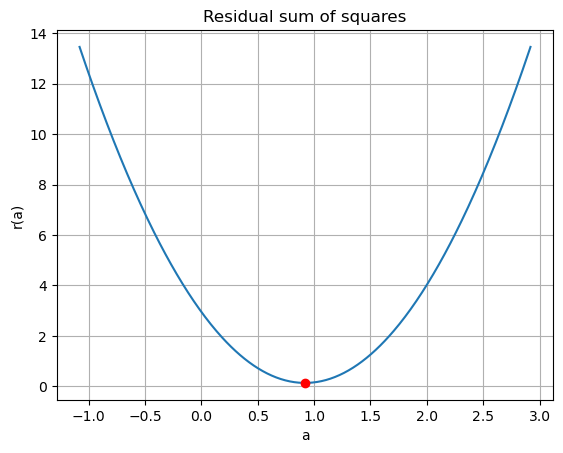

In [34]:
a_grid = np.linspace(a - 2, a + 2, 400)
r_grid = [sum((yi - candidate_a * xi)**2 for xi, yi in zip(x, y))
          for candidate_a in a_grid]

plt.plot(a_grid, r_grid)
plt.scatter(a, sum(residual**2 for residual in r), color="red", zorder=3)
plt.xlabel("a")
plt.ylabel("r(a)")
plt.title("Residual sum of squares")
plt.grid(True)
plt.show()


In [41]:
def affineLS(x,y):
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    a = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
    b = y_mean - a * x_mean
    R = [(yi - (a * xi + b)) for xi, yi in zip(x, y)]
    return b, a, R



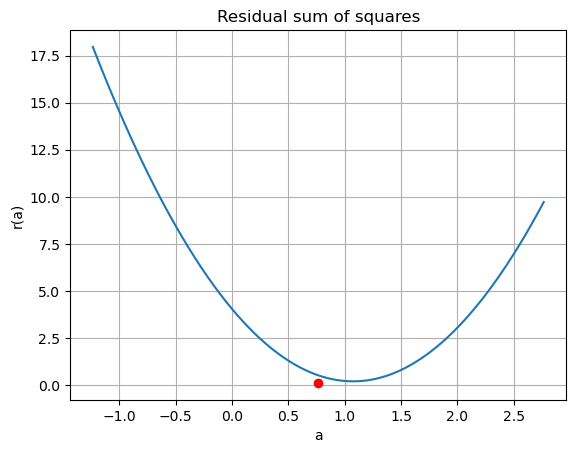

0.10040670847559319 0.7652890672990385 [-0.08642319395437204, 0.1861389123012529, 0.06888258739160874, -0.0044726503907085435, -0.015398351452121983, -0.12488593020099698, -0.019679290295852803, -0.17835702347109317, 0.05000657133469533, 0.12418836873758951]


In [43]:
b,a,R = affineLS(x,y)
a_grid = np.linspace(a - 2, a + 2, 400)
r_grid = [sum((yi - (candidate_a * xi)+b)**2 for xi, yi in zip(x, y))
          for candidate_a in a_grid]

plt.plot(a_grid, r_grid)
plt.scatter(a, sum(residual**2 for residual in R), color="red", zorder=3)
plt.xlabel("a")
plt.ylabel("r(a)")
plt.title("Residual sum of squares")
plt.grid(True)
plt.show()
print(b,a,R)